In [1]:
from itertools import chain
import anndata as ad
import itertools
import networkx as nx
import pandas as pd
import scanpy as sc
import scglue
import seaborn as sns
from matplotlib import rcParams

/environment/miniconda3/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/environment/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

In [3]:
rna = ad.read_h5ad("MISAR-rna-pp.h5ad")
atac = ad.read_h5ad("MISAR-atac-pp.h5ad")
guidance = nx.read_graphml("MISAR-guidance.graphml.gz")

In [4]:
scglue.models.configure_dataset(
    rna, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca"
)

In [5]:
scglue.models.configure_dataset(
    atac, "NB", use_highly_variable=True,
    use_rep="X_lsi"
)

In [6]:
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    atac.var.query("highly_variable").index
)).copy()

In [7]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "atac": atac}, guidance_hvf,
    fit_kws={"directory": "glue"}
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using GPU 0 as computation device.
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 16009
[INFO] SCGLUEModel: Setting `max_epochs` = 802
[INFO] SCGLUEModel: Setting `patience` = 67
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 34
[INFO] SCGLUETrainer: Using training directory: "glue/pretrain"


/environment/miniconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.619, 'g_kl': 0.006, 'g_elbo': 0.625, 'x_rna_nll': 0.37, 'x_rna_kl': 0.008, 'x_rna_elbo': 0.377, 'x_atac_nll': 0.381, 'x_atac_kl': 0.004, 'x_atac_elbo': 0.386, 'dsc_loss': 0.675, 'vae_loss': 0.788, 'gen_loss': 0.754}, val={'g_nll': 0.614, 'g_kl': 0.006, 'g_elbo': 0.621, 'x_rna_nll': 0.365, 'x_rna_kl': 0.007, 'x_rna_elbo': 0.371, 'x_atac_nll': 0.386, 'x_atac_kl': 0.004, 'x_atac_elbo': 0.39, 'dsc_loss': 0.688, 'vae_loss': 0.786, 'gen_loss': 0.752}, 2.1s elapsed
[INFO] SCGLUETrainer: [Epoch 20] train={'g_nll': 0.593, 'g_kl': 0.009, 'g_elbo': 0.602, 'x_rna_nll': 0.358, 'x_rna_kl': 0.005, 'x_rna_elbo': 0.364, 'x_atac_nll': 0.365, 'x_atac_kl': 0.002, 'x_atac_elbo': 0.367, 'dsc_loss': 0.689, 'vae_loss': 0.754, 'gen_loss': 0.72}, val={'g_nll': 0.592, 'g_kl': 0.009, 'g_elbo': 0.602, 'x_rna_nll': 0.353, 'x_rna_kl': 0.005, 'x_rna_elbo': 0.358, 'x_atac_nll': 0.364, 'x_atac_kl': 0.002, 'x_atac_elbo': 0.366, 'dsc_loss': 0.698, 'vae_loss': 0.748, 'gen

2025-11-19 01:36:08,147 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "237"...
[INFO] EarlyStopping: Restoring checkpoint "237"...
[INFO] fit_SCGLUE: Estimating balancing weight...
[INFO] estimate_balancing_weight: Clustering cells...


...

[INFO] estimate_balancing_weight: Matching clusters...
[INFO] estimate_balancing_weight: Matching array shape = (11, 15)...
[INFO] estimate_balancing_weight: Estimating balancing weight...
[INFO] fit_SCGLUE: Fine-tuning SCGLUE model...
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 16009
[INFO] SCGLUEModel: Setting `align_burnin` = 134
[INFO] SCGLUEModel: Setting `max_epochs` = 802
[INFO] SCGLUEModel: Setting `patience` = 67
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 34
[INFO] SCGLUETrainer: Using training directory: "glue/fine-tune"


/environment/miniconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.459, 'g_kl': 0.012, 'g_elbo': 0.471, 'x_rna_nll': 0.341, 'x_rna_kl': 0.006, 'x_rna_elbo': 0.348, 'x_atac_nll': 0.342, 'x_atac_kl': 0.002, 'x_atac_elbo': 0.344, 'dsc_loss': 0.684, 'vae_loss': 0.71, 'gen_loss': 0.676}, val={'g_nll': 0.459, 'g_kl': 0.012, 'g_elbo': 0.471, 'x_rna_nll': 0.352, 'x_rna_kl': 0.006, 'x_rna_elbo': 0.358, 'x_atac_nll': 0.348, 'x_atac_kl': 0.002, 'x_atac_elbo': 0.35, 'dsc_loss': 0.711, 'vae_loss': 0.727, 'gen_loss': 0.691}, 2.0s elapsed
[INFO] SCGLUETrainer: [Epoch 20] train={'g_nll': 0.456, 'g_kl': 0.012, 'g_elbo': 0.468, 'x_rna_nll': 0.343, 'x_rna_kl': 0.006, 'x_rna_elbo': 0.349, 'x_atac_nll': 0.346, 'x_atac_kl': 0.002, 'x_atac_elbo': 0.348, 'dsc_loss': 0.689, 'vae_loss': 0.715, 'gen_loss': 0.681}, val={'g_nll': 0.456, 'g_kl': 0.012, 'g_elbo': 0.468, 'x_rna_nll': 0.357, 'x_rna_kl': 0.006, 'x_rna_elbo': 0.363, 'x_atac_nll': 0.354, 'x_atac_kl': 0.002, 'x_atac_elbo': 0.355, 'dsc_loss': 0.717, 'vae_loss': 0.738, 'ge

2025-11-19 01:45:45,450 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "237"...
[INFO] EarlyStopping: Restoring checkpoint "237"...


In [8]:
glue.save("MISAR-glue.dill")
# glue = scglue.models.load_model("glue.dill")

In [9]:
dx = scglue.models.integration_consistency(
    glue, {"rna": rna, "atac": atac}, guidance_hvf
)
dx

[INFO] integration_consistency: Using layer "counts" for modality "rna"
[INFO] integration_consistency: Selecting aggregation "sum" for modality "rna"
[INFO] integration_consistency: Selecting aggregation "sum" for modality "atac"
[INFO] integration_consistency: Selecting log-norm preprocessing for modality "rna"
[INFO] integration_consistency: Selecting log-norm preprocessing for modality "atac"
[INFO] get_metacells: Clustering metacells...


[WARNING] get_metacells: `faiss` is not installed, using `sklearn` instead... This might be slow with a large number of cells. Consider installing `faiss` following the guide from https://github.com/facebookresearch/faiss/blob/main/INSTALL.md


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 10 common metacells...
[INFO] get_metacells: Clustering metacells...


[WARNING] get_metacells: `faiss` is not installed, using `sklearn` instead... This might be slow with a large number of cells. Consider installing `faiss` following the guide from https://github.com/facebookresearch/faiss/blob/main/INSTALL.md


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 20 common metacells...
[INFO] get_metacells: Clustering metacells...


...

[WARNING] get_metacells: `faiss` is not installed, using `sklearn` instead... This might be slow with a large number of cells. Consider installing `faiss` following the guide from https://github.com/facebookresearch/faiss/blob/main/INSTALL.md


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 100 common metacells...
[INFO] get_metacells: Clustering metacells...


[WARNING] get_metacells: `faiss` is not installed, using `sklearn` instead... This might be slow with a large number of cells. Consider installing `faiss` following the guide from https://github.com/facebookresearch/faiss/blob/main/INSTALL.md


[INFO] get_metacells: Aggregating metacells...
[INFO] metacell_corr: Computing correlation on 200 common metacells...


,n_meta,consistency
0,10,0.171991
1,20,0.114673
2,50,0.076758
3,100,0.052554
4,200,0.044683


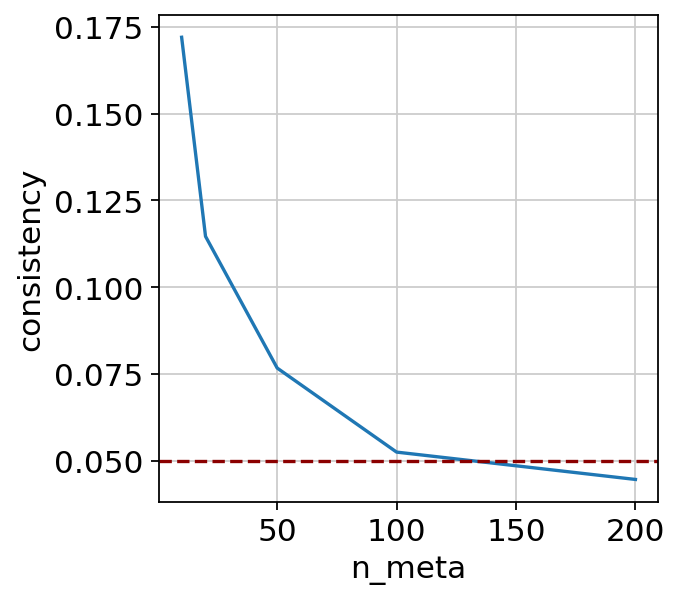

In [10]:
_ = sns.lineplot(x="n_meta", y="consistency", data=dx).axhline(y=0.05, c="darkred", ls="--")

In [11]:
rna.obsm["X_glue"] = glue.encode_data("rna", rna)
atac.obsm["X_glue"] = glue.encode_data("atac", atac)

In [12]:
combined = ad.concat([rna, atac])

/environment/miniconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1830: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


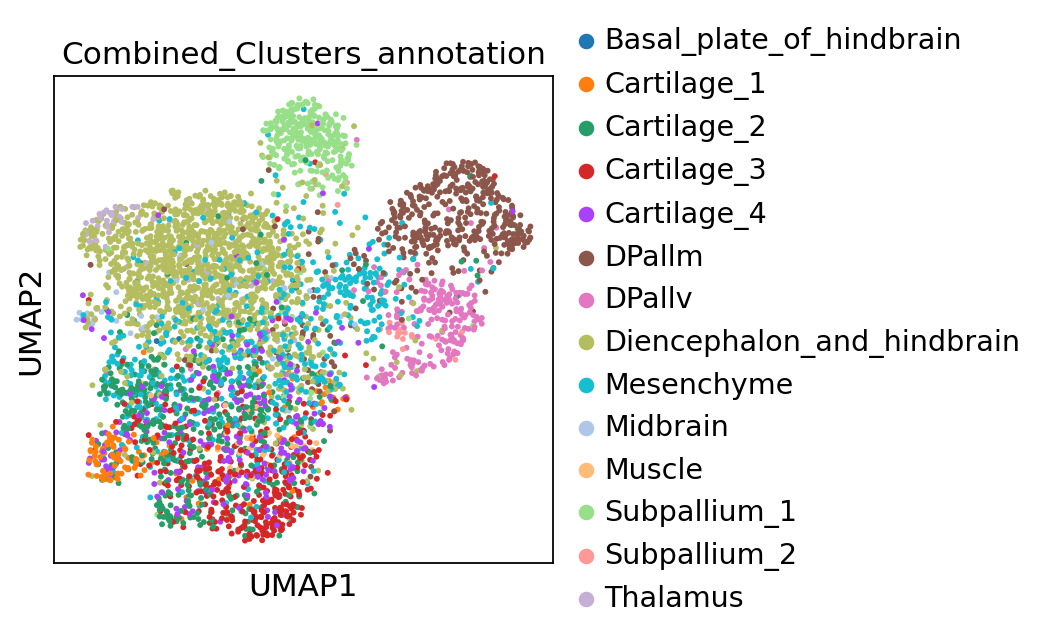

In [13]:
sc.pp.neighbors(combined, use_rep="X_glue", metric="cosine")
sc.tl.umap(combined)
sc.pl.umap(combined, color=["Combined_Clusters_annotation"], wspace=0.65)

In [14]:
feature_embeddings = glue.encode_graph(guidance_hvf)
feature_embeddings = pd.DataFrame(feature_embeddings, index=glue.vertices)
feature_embeddings.iloc[:5, :5]

,0,1,2,3,4
1110002J07Rik,-0.000057,-0.585694,0.295454,0.258401,0.003037
1110020A21Rik,-0.004667,-0.033609,0.166565,0.264837,-0.000769
1110032A03Rik,-0.004216,0.019660,-0.319426,-0.694326,-0.001701
1110032F04Rik,0.001235,-0.258161,0.648510,0.213284,0.003703
1110046J04Rik,-0.000503,-0.270924,0.362636,0.171818,0.006416


In [15]:
rna.varm["X_glue"] = feature_embeddings.reindex(rna.var_names).to_numpy()
atac.varm["X_glue"] = feature_embeddings.reindex(atac.var_names).to_numpy()

In [16]:
rna.write("MISAR-rna-emb.h5ad", compression="gzip")
atac.write("MISAR-atac-emb.h5ad", compression="gzip")
nx.write_graphml(guidance_hvf, "MISAR-guidance-hvf.graphml.gz")